# Leapfrog Method: Finite-difference scheme for the 1D two-wave equation


The Leapfrog method is a 3-level time-stepping scheme (hence, the name). It results from applying the finite difference formulae to the second-order wave equation:

$$\frac{\partial^2 \rho(x,t)}{\partial t^2} = c^2 \frac{\partial^2 \rho(x,t)}{\partial x^2}$$

- It is called **leapfrog** because the calculation for the state at the next time step ($j+1$) "leaps" over the current step ($j$) by using information from the previous step ($j-1$) to compute the update. 

- In computational physics, this name also refers to the way variables (like position and velocity) can be updated at staggered time intervals, essentially leaping over each other to maintain second-order accuracy and stability.


We discretise the two-wave equation (PDE) using finite differences:

- The spatial and time steps are: $\Delta x = \frac{x_f - x_0}{N_x}$, $\Delta t = \frac{t_f - t_0}{N_t}$.
  
- Grid points: $x_i = x_0 + i\Delta x$, $t_j = t_0 + j\Delta t$.

- The numerical solution is: $\rho_i^j \approx \rho(x_i, t_j)$.

Using central differences in both time and space:

- Time derivative: $\frac{\partial^2 \rho}{\partial t^2} \approx \frac{\rho_i^{j+1} - 2\rho_i^j + \rho_i^{j-1}}{\Delta t^2}$

- Space derivative: $\frac{\partial^2 \rho}{\partial x^2} \approx \frac{\rho_{i+1}^j - 2\rho_i^j + \rho_{i-1}^j}{\Delta x^2}$

$$\Rightarrow \frac{\rho_i^{j+1} - 2\rho_i^j + \rho_i^{j-1}}{\Delta t^2}= c^2 \frac{\rho_{i+1}^j - 2\rho_i^j + \rho_{i-1}^j}{\Delta x^2}$$

Rewriting, we obtain the update formula:

$$\rho_i^{j+1} = r(\rho_{i+1}^j - 2\rho_i^j + \rho_{i-1}^j) + 2\rho_i^j - \rho_i^{j-1}$$

where $r = \frac{c^2 \Delta t^2}{\Delta x^2}$




## Harmonic density waves:

We need to solve the 1D Wave Equation with second-order Finite Differences:

### Problem Statement

We wish to solve the **1D wave equation**:

$$
\frac{\partial^2 \rho(x,t)}{\partial t^2} = c^2 \frac{\partial^2 \rho(x,t)}{\partial x^2},
$$

on the domain $x \in [0, 1]$, $t \in [0, 2]$, with wave speed $c = 1$. The problem is subject to:

- **Initial condition**:
$
\rho(x,0) = \sin(\pi x), \quad \left.\frac{\partial \rho}{\partial t}\right|_{t=0} = \sin(\pi x)
$

- **Boundary conditions**:
$
\rho(0,t) = 0, \quad \rho(1,t) = 0.
$

The **analytical solution** to this problem is:

$$
\rho_{\text{exact}}(x,t) = \sin(\pi x) \left[\cos(\pi t) + \frac{\sin(\pi t)}{\pi}\right]
$$


### Tasks:

1. Define the spatial and temporal domain.

2. Initialize an empty array to store the solution.

3. Apply initial and boundary conditions:

   - First time step from $\rho(x,0)$
   
   - Second time step using Taylor expansion and $\partial \rho/\partial t$.
  
### The Initialization Step (First Time Level):

The Leapfrog scheme is a 3-level method, meaning to calculate the state at $j+1$, we require information from the two previous time levels, $j$ and $j-1$. Consequently, the algorithm cannot start at $j=0$ because the $j=-1$ level is not defined. We must **bootstrap** the simulation by calculating the first time step ($j=1$) using the initial conditions.

#### Taylor Expansion in Time:

To find the value of $\rho$ at the first time step $\Delta t$, we perform a first-order Taylor expansion around $t=0$:

$$\rho(x, \Delta t) = \rho(x, 0) + \Delta t \left. \frac{\partial \rho}{\partial t} \right|_{t=0} + \mathcal{O}(\Delta t^2)$$

#### Applying Initial Conditions:

Based on the problem setup:

- Initial Position ($j=0$): $\rho(x, 0) = \sin(\pi x)$

- Initial Velocity: $\left. \frac{\partial \rho}{\partial t} \right|_{t=0} = \sin(\pi x)$

#### The Startup Formula becomes:

Substituting these values into the expansion gives us the expression for the second row of our numerical matrix:

$$\rho_i^1 = \sin(\pi x) + \Delta t \sin(\pi x)$$

$$\rho_i^1 = \sin(\pi x) (1 + \Delta t)$$

In the Python code, this corresponds to:
```python
rho_num[:, 1] = np.sin(np.pi*x)*(1 + delta_t)
```
    
4. Iterate using the finite difference update formula for time steps $j = 1$ to $N_t - 1$.

5. Compute the **$||L_2||$ error** against the exact solution:

$$
||L_2|| = \sqrt{\frac{1}{(N_x+1)(N_t+1)}\sum_{i,j} \left(\rho_i^j - \rho_{\text{exact}}(x_i, t_j)\right)^2}
$$

6. Compute and visualise the analytical solution surface and compare against the numerical result.

In [1]:
import numpy as np

import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import axes3d

In [2]:
# Discretisation
N_x = 100
N_t = 200

# x-Limits
x_0 = 0.
x_f = 1.01

# t-Limits
t_0 = 0
t_f = 2

# Step sizes
delta_x = (x_f - x_0)/N_x
delta_t = (t_f - t_0)/N_t

# Axes
x = np.arange(x_0, x_f + delta_x, delta_x)
t = np.arange(t_0, t_f + delta_t, delta_t)

# Meshgrid
X, Y = np.meshgrid(x, t)

In [3]:
print(delta_x, delta_t)

0.0101 0.01


The **analytical solution** to this problem is:

$$
\rho_{\text{exact}}(x,t) = \sin(\pi x) \left[\cos(\pi t) + \frac{\sin(\pi t)}{\pi}\right]
$$

In [4]:
# Function for the analytical solution

def exact_sln(XX, YY):
    
    sln = np.sin(np.pi*XX)*(np.cos(np.pi*YY) + np.sin(np.pi*YY)/np.pi)
    
    return sln

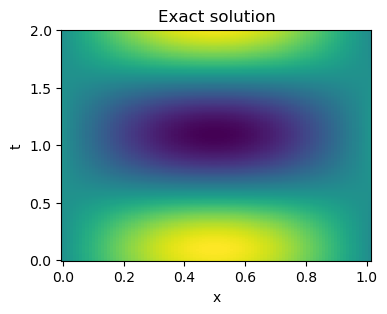

In [5]:
# Surface plot
Z_exact = exact_sln(X, Y)

# Plotting
plt.figure(figsize=(4,3))

plt.title("Exact solution")

plt.pcolor(X, Y, Z_exact, cmap = 'viridis')

plt.xlabel("x")
plt.ylabel("t")

plt.show()

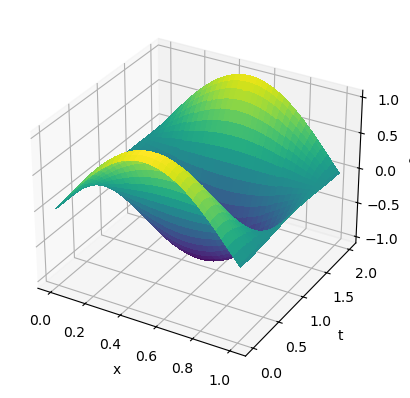

In [6]:
fig = plt.figure()

ax = plt.axes(projection='3d')
#ax.contour3D(x_grid, t_grid, u, 1000, cmap='viridis') # Creates 'n=10' contours at different Z to make the surface

ax.plot_surface(X, Y, Z_exact, cmap='viridis', linewidth=0, antialiased=False)

ax.set_xlabel('x')  # Customised labels for axes
ax.set_ylabel('t')
ax.set_zlabel(r'$\rho$')

plt.show()

## Numerical solution using central differences:

In [7]:
# Create our domain, empty matrix

rho_num = np.zeros((N_x + 1, N_t + 1))

# We want to enforce the right-side BC to be 0

#print(rho_num.shape)

In [8]:
# Boundary conditions
rho_num[0, :] = 0.
rho_num[-1, :] = 0.

# Initial conditions
rho_num[:, 0] = np.sin(np.pi*x)

#print(rho_num.T)

### Pivot step:

$$\rho(x,\Delta t) = \sin(\pi\,x)(1+\Delta t)$$

In [9]:
# Second row of the matrix (we used the derivative information)

rho_num[:, 1] = np.sin(np.pi*x)*(1 + delta_t)


In [10]:
#print(X.shape, Y.shape, rho_num.shape)

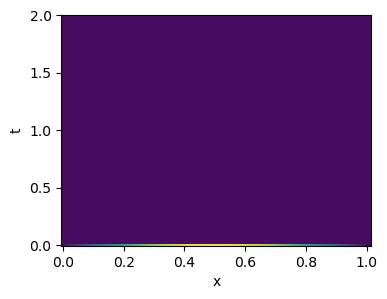

In [11]:
# Plot to check the matrix
plt.figure(figsize=(4,3))

plt.pcolor(X, Y, rho_num.T, cmap = 'viridis')

plt.xlabel("x")
plt.ylabel("t")

plt.show()

### Define r

In [12]:
# Speed
c = 1.

# Factor in front of the derivatives
r_factor = c**2*delta_t**2/delta_x**2

In [13]:
# Numerical solution - we need a FOR loop

# Time loop
for j in range(1, N_t):

    # Spatial loop
    for i in range(1, N_x-1):
        
        rho_num[i, j+1] = r_factor*(rho_num[i-1, j]\
        - 2*rho_num[i, j] + rho_num[i+1, j])\
        + 2*rho_num[i, j] - rho_num[i, j-1]

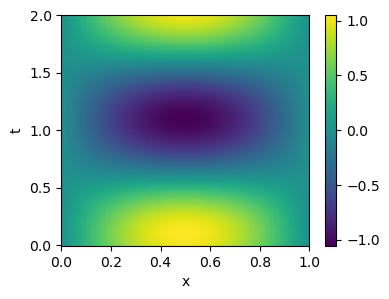

In [14]:
# Plot full solution
plt.figure(figsize=(4,3))

z_s = plt.pcolor(X, Y, rho_num.T, cmap = 'viridis')

plt.xlabel("x")
plt.ylabel("t")

plt.colorbar(z_s)

plt.xlim(0,1)

plt.show()

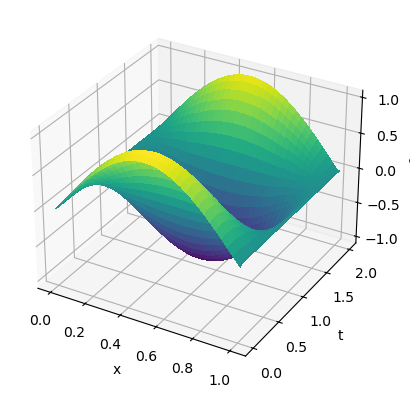

In [15]:
fig = plt.figure()

ax = plt.axes(projection='3d')
#ax.contour3D(x_grid, t_grid, u, 1000, cmap='viridis') # Creates 'n=10' contours at different Z to make the surface

ax.plot_surface(X, Y, rho_num.T, cmap='viridis', linewidth=0, antialiased=False)

ax.set_xlabel('x')  # Customised labels for axes
ax.set_ylabel('t')
ax.set_zlabel(r'$\rho$')

plt.show()

### Error map

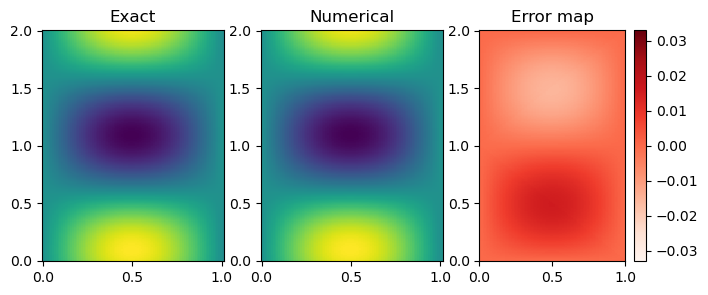

In [16]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (8,3))

ax1.pcolor(X, Y, Z_exact, cmap = 'viridis')
ax1.set_title("Exact")
#plt.xlim(0,1)

ax2.pcolor(X, Y, rho_num.T, cmap = 'viridis')
ax2.set_title("Numerical")
#plt.xlim(0,1)

surf3 = ax3.pcolor(X, Y, rho_num.T - Z_exact, cmap = 'Reds')
ax3.set_title("Error map")
plt.colorbar(surf3)
plt.xlim(0,1)

plt.show()

### $L_2$ norm error

$$
||L_2|| = \sqrt{\frac{1}{(N_x+1)(N_t+1)}\sum_{i,j} \left(\rho_i^j - \rho_{\text{exact}}(x_i, t_j)\right)^2}
$$

In [17]:
L2_error = np.sqrt(np.sum((rho_num.T - Z_exact)**2)\
         /((N_x + 1)*(N_t + 1)))

In [18]:
print(L2_error)

0.00795240283720567
